Le projet a été réalisé par Bastien Monjot et Jeremy Guillot

Ce notebook propose une reproduction partielle des expériences de l’article en utilisant la bibliothèque DeepInverse, avec un protocole simplifié adapté aux contraintes de calcul.

# Introduction

Dans ce projet, nous étudions l’article intitulé Image Restoration using Total Variation Regularized Deep Image Prior, rédigé par Jiaming Liu, Yu Sun, Xiaojian Xu et Ulugbek S. Kamilov.

Nous présentons tout d’abord le problème inverse considéré dans cet article ainsi que le modèle proposé pour le résoudre. Nous décrivons ensuite la méthode DIP-TV, qui constitue la principale contribution de l’article, et nous la comparons aux approches existantes.

Enfin, nous reproduisons partiellement les expériences présentées dans l’article, en particulier pour les problèmes de débruitage et de défloutage d’images.

# Description du Problème inverse

Le problème inverse considéré dans cet article est un problème inverse de restauration d’image. On pose pour cela le problème suivant :
y = Hx + ε
où

x est l’image originale inconnue
la reconstruction est notée x̂

H est un opérateur linéaire de dégradation

y est une observation dégradée mesurée

ε correspond au bruit de mesure supposé gaussien de variance σ²

Le problème inverse consiste à estimer l’image x à partir d’une observation bruitée ou floutée y.

Le type de dégradation utilisé dans ce problème est le floutage et le débruitage.

Avec le débruitage, où H = I et ε correspond à un bruit gaussien additif, avec la formule H = I ⇒ y = x + ε.
Et le défloutage, avec H qui est une convolution par un noyau et un bruit gaussien, avec la formule y = k * x + ε.


# Description de la méthode

### Explication de la méthode

La méthode utilisée pour résoudre ce problème est DIP-TV qui est la combinaison de deux méthodes le Deep Image Prior (DIP) et la Total Variation (TV). On fait le choix de la combinaison car DIP seul peut sur-apprendre le bruit et TV seule perd des détails. La méthode DIP-TV essaye de faire le compromis entre les deux méthodes.

### Description de la méthode

Principe Général :

L'idée est de réprésenté l'image à reconstruire comme la sortie d'un réseau de neurones CNN. Le réseau prend en entrée un bruit aléatoire fixe z et génère une image f_Θ(z) où Θ désigne les paramètres du réseau.  La méthode DIP utilise la fonction suivante :

min ||y-Hf_Θ(z))||²

D'après l'article on ajoute une régularisation de type TV. l'équation devient donc
minΘ||y-HfΘ(z)||+λρTV(fθ(z)) avec λ qui controle le compromis entre régularisation et fidelité à l'image.

Et cela transforme ensuite en problème d'optimisation qui est le suivant
Θ = minΘ||y-HfΘ(z)||+λρTV(fθ(z))

Cette approche se rapproche de l'entrainement du CNN qui est utilisé dans cette algorithme nottament avec la fonction suivante min ||y - Hf_Θ(z))||².

L'image restaurée finale est la sortie du réseau optimisé x*=fΘ*(z)

On utilise comme architecture du CNN cela permet de capturer à la fois la structure globale et les détails locaux de l'image en utilisant le skip connections.

# Nouveauté

Avant l'utilisation du DIP-TV, nous utilisions le TV tout seul, qui permettait une régularisation. L'avantage de cette méthode était la bonne suppression du bruit, mais quand le bruit est trop important, on a une perte d'information à cause d'une perte de texture et d'un lissage excessif. Une autre méthode qui était utilisée avant la méthode proposée dans l'article est les méthodes de deep learning comme les CNN, mais elles nécessitent un entraînement avec une dépendance aux données et sont moins flexibles en cas de changement de dégradation. La dernière méthode qui existait avant était le DIP, qui était un prior sans entraînement utilisant un réseau de type CNN non entraîné. Mais la limite est qu'il peut être sur-entraîné et dépendant des itérations.

La nouveauté présentée dans l’article est la combinaison du Deep Image Prior, qui utilise un réseau de type CNN non entraîné comme prior implicite pour l’image, et d’une méthode de régularisation de type Total Variation (TV) comme prior variationnel. La méthode proposée, appelée DIP-TV, introduit une pénalisation TV directement sur l’image génèrée par le réseau DIP. Cela permet d’améliorer les performances du DIP en exploitant les propriétés de régularisation de la TV.
L'intérêt de cette nouvelle méthode, c'est qu'elle utilise les qualités du DIP et du TV en les renforçant. Les principales qualités sont la réduction du sur-apprentissage, une meilleure stabilité avec des bruits élevés et le fait qu'elle n'utilise pas d'entraînement.

La méthode de DIP-TV est moins performants que les méthodes utilisant l'entrainement des CNN, mais le fait qu'elle n'utilise pas d'entraînement constitue un meilleur compromis entre performances et coût de calcul.

## Compréhension des résultats.

Sur l’analyse des résultats présentés dans l’article, on voit que l’image bruitée contient beaucoup de bruit et que l’utilisation du DIP seul améliore la netteté de l’image et permet de réduire le bruit. La méthode TV permet de lisser les images en réduisant les variations. Enfin, l’utilisation du DIP-TV permet d’améliorer significativement l’image bruitée. On peut faire les mêmes observations avec le floutage.

On voit d’après les résultats de l’article que les résultats du DIP-TV améliorent les performances par rapport aux autres méthodes et les résultats sont encore plus importants lorsque la valeur de σ augmente. Quand on fait une étude du sigma, on voit que les méthodes classique ont des meilleurs résultats que DIP-TV mais lorsque sigma augmente les résultats du DIP-TV deviennent meilleurs par rapport aux autres méthodes.

Cela montre que la combinaison des méthodes DIP et TV améliore les résultats par rapport aux autres modèles, avec DIP qui agit comme un prior implicite et TV qui agit comme un mécanisme de lissage. Le fait de combiner ces deux méthodes montre que nous pouvons améliorer les méthodes qui existaient jusqu’à aujourd’hui pour la restauration d’image.

##Réalisation des expérimentations

Pour réaliser les expérimentations, nous considérons dans un premier temps un problème de débruitage d’image. Les méthodes seront testées avec un paramètre de régularisation fixé à λ = 1e-2 et un nombre d’itérations fixé à 2000.

Nous testerons plusieurs niveaux de bruit gaussien σ afin d’observer l’évolution des performances des différentes méthodes lorsque le niveau de bruit augmente. Nous comparerons trois approches : le Deep Image Prior (DIP) seul, la régularisation TV seule et la méthode DIP-TV proposée dans l’article.

Dans un second temps, nous étudierons un problème de défloutage d’image. Les mêmes paramètres d’optimisation seront utilisés. Nous appliquerons la méthode DIP-TV et comparerons les résultats obtenus à une reconstruction simple obtenue à partir de l’opérateur adjoint.

Les performances des différentes méthodes seront évaluées à l’aide du PSNR.

D'après l'article, les résultats sont majoritairement évalués à l'aide du SNR. Dans nos expérimentations, nous utiliserons le PSNR (Peak Signal-to-Noise Ratio). Ces deux métriques sont couramment utilisées dans le domaine de la restauration d'images pour évaluer la qualité d'une reconstruction. Les deux résultats ne sont pas comparables mais cela permet d'arriver à la même tendance que l'article.

Nous avons sélectionné des images de chat pour réaliser les expérimentations du sujet

Nous avons fait le choix, pour la reproduction partielle, d’effectuer 2000 itérations afin d’optimiser le coût de calcul. En effet, le lancement des expériences prend déjà environ 5 minutes, et augmenter le nombre d’itérations allongerait considérablement le temps d’exécution.

###Installation des packages

In [ ]:
pip install deepinv torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.4/850.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 66.8 MB/s eta 0:00:00


In [ ]:
import torch
import deepinv as dinv
import torch.nn.functional as F
import pandas as pd


In [ ]:


# import d'exemple (souvent dispo dans deepinv)
from deepinv.utils import load_example
from deepinv.utils.plotting import plot

# PSNR : selon version
try:
    from deepinv.loss.metric import PSNR
except Exception:
    try:
        from deepinv.metric import PSNR
    except Exception:
        PSNR = None




###Sélection de l'image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Image de test (couleur) - tu peux changer
x = load_example("cat.jpg", img_size=256).to(device)  # (1,C,H,W)

device: cuda


###Débruitage

In [ ]:
def tv_anisotropic(x: torch.Tensor) -> torch.Tensor:
    """
    TV anisotrope: sum |dx| + |dy|
    x: (B,C,H,W)
    """
    dx = x[..., :, 1:] - x[..., :, :-1]
    dy = x[..., 1:, :] - x[..., :-1, :]
    return dx.abs().sum() + dy.abs().sum()


def build_dip_backbone(img_size, in_size=(2, 2), channels=64):
    """
    Essaye de construire un backbone DIP selon la version deepinv.
    - Priorité: ConvDecoder (souvent utilisé pour DIP)
    - Fallback: UNet si disponible
    """
    # ConvDecoder
    if hasattr(dinv.models, "ConvDecoder"):
        return dinv.models.ConvDecoder(
            img_size=img_size, in_size=list(in_size), channels=channels
        )
    # UNet fallback
    if hasattr(dinv.models, "UNet"):
        # Certains UNet exigent des args différents selon versions.
        # On prend une config minimale si possible.
        try:
            c, h, w = img_size
            return dinv.models.UNet(in_channels=channels, out_channels=c)
        except Exception:
            pass

    raise AttributeError("Impossible de trouver un modèle DIP (ConvDecoder/UNet) dans ta version de deepinv.")


def dip_optimize(
    y,
    physics,
    lam_tv=0.0,
    iterations=2000,
    lr=1e-2,
    channels=64,
    in_size=(2, 2),
    seed=0,
    verbose_every=200,
):
    """
    Optimise θ pour minimiser:
        || y - H f_θ(z) ||^2 + lam_tv * TV(f_θ(z))
    - lam_tv=0 -> DIP
    - lam_tv>0 -> DIP-TV
    """
    torch.manual_seed(seed)
    device = y.device

    # Backbone
    backbone = build_dip_backbone(img_size=y.shape[1:], in_size=in_size, channels=channels).to(device)

    # Entrée bruit z FIXE (DIP classique)
    z = torch.randn((y.shape[0], channels, in_size[0], in_size[1]), device=device)

    opt = torch.optim.Adam(backbone.parameters(), lr=lr)

    best_x = None
    best_loss = float("inf")

    for it in range(iterations):
        opt.zero_grad()
        x_hat = backbone(z)                  # fθ(z)
        y_hat = physics.A(x_hat)             # H fθ(z)

        data = ((y_hat - y) ** 2).mean()
        loss = data

        if lam_tv > 0:
            tv = tv_anisotropic(x_hat) / x_hat.numel()
            loss = loss + lam_tv * tv

        loss.backward()
        opt.step()

        # garder le meilleur (pratique si pas d'early stopping)
        L = loss.item()
        if L < best_loss:
            best_loss = L
            best_x = x_hat.detach().clone()

        if verbose_every and (it + 1) % verbose_every == 0:
            if lam_tv > 0:
                print(f"it={it+1:4d}  data={data.item():.6g}  tv={tv.item():.6g}  loss={L:.6g}")
            else:
                print(f"it={it+1:4d}  data={data.item():.6g}  loss={L:.6g}")

    return best_x


In [ ]:
def grad_forward(x):
    # x: (B,C,H,W)
    gx = x[..., :, 1:] - x[..., :, :-1]   # (B,C,H,W-1)
    gy = x[..., 1:, :] - x[..., :-1, :]   # (B,C,H-1,W)
    return gx, gy

def div_backward(px, py, H, W):
    # px: (B,C,H,W-1), py: (B,C,H-1,W)
    out = torch.zeros((px.shape[0], px.shape[1], H, W), device=px.device, dtype=px.dtype)
    out[..., :, :-1] -= px
    out[..., :, 1:]  += px
    out[..., :-1, :] -= py
    out[..., 1:, :]  += py
    return out

@torch.no_grad()
def prox_tv_anisotropic(v, weight, n_iters=80):
    """
    Prox de TV anisotrope approx (Chambolle-like, stable).
    Résout prox_{weight*TV}(v).
    v: (B,C,H,W)
    """
    if weight <= 0:
        return v

    B, C, H, W = v.shape
    px = torch.zeros((B, C, H, W-1), device=v.device, dtype=v.dtype)
    py = torch.zeros((B, C, H-1, W), device=v.device, dtype=v.dtype)
    tau = 0.25

    for _ in range(n_iters):
        div_p = div_backward(px, py, H, W)
        x = v - weight * div_p
        gx, gy = grad_forward(x)

        px = px + (tau / weight) * gx
        py = py + (tau / weight) * gy

        # projection anisotrope: |p| <= 1 composante par composante
        px = px / torch.maximum(torch.ones_like(px), px.abs())
        py = py / torch.maximum(torch.ones_like(py), py.abs())

    x = v - weight * div_backward(px, py, H, W)
    return x

@torch.no_grad()
def tv_fista_denoise(y, lam_tv=0.08, n_iters=200, prox_iters=80):
    """
    TV denoising : min_x 0.5||x - y||^2 + lam_tv * TV(x)
    => A=I, donc FISTA très simple (gradient Lipschitz = 1)
    """
    x = y.clone()
    z = x.clone()
    t = 1.0
    step = 1.0  # since A=I

    for _ in range(n_iters):
        # grad of 0.5||z-y||^2 is (z-y)
        v = z - step * (z - y)
        x_new = prox_tv_anisotropic(v, weight=step * lam_tv, n_iters=prox_iters)

        t_new = 0.5 * (1.0 + (1.0 + 4.0 * t * t) ** 0.5)
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)

        x, t = x_new, t_new

    return x


/usr/local/lib/python3.12/dist-packages/deepinv/physics/forward.py:68: UserWarning: Arguments {'device': device(type='cuda')} are passed to Denoising but are ignored.
  warnings.warn(


it= 200  data=0.0164842  loss=0.0164842
it= 400  data=0.01485  loss=0.01485
it= 600  data=0.0145999  loss=0.0145999
it= 800  data=0.0139094  loss=0.0139094
it=1000  data=0.0138069  loss=0.0138069
it=1200  data=0.0136139  loss=0.0136139
it=1400  data=0.0134817  loss=0.0134817
it=1600  data=0.0131925  loss=0.0131925
it=1800  data=0.0128841  loss=0.0128841
it=2000  data=0.0128216  loss=0.0128216
it= 200  data=0.0164742  tv=0.0113074  loss=0.0165872
it= 400  data=0.0148247  tv=0.0137076  loss=0.0149618
it= 600  data=0.0146367  tv=0.0145112  loss=0.0147818
it= 800  data=0.0144522  tv=0.0150423  loss=0.0146027
it=1000  data=0.0138084  tv=0.015686  loss=0.0139653
it=1200  data=0.0135119  tv=0.0166057  loss=0.013678
it=1400  data=0.0131839  tv=0.0172754  loss=0.0133567
it=1600  data=0.0133064  tv=0.017854  loss=0.0134849
it=1800  data=0.0130664  tv=0.0187929  loss=0.0132543
it=2000  data=0.0129744  tv=0.0204752  loss=0.0131792
sigma=25 | PSNR noisy=20.16 | TV=26.32 | DIP=24.68 | DIP-TV=24.77
i

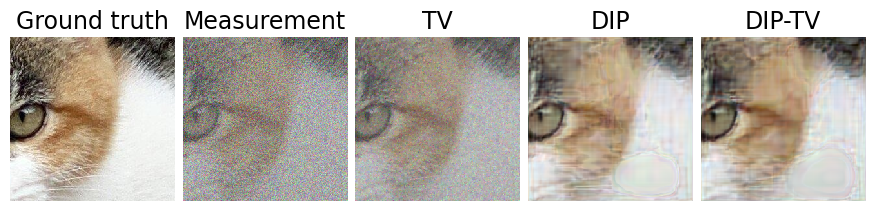

In [ ]:
psnr = PSNR() if PSNR is not None else None

sigmas = [25, 35, 45, 55, 65, 75]  # comme Table 2 (échelle 0..255)
results = []

for s in sigmas:
    sigma = s / 255.0

    physics = dinv.physics.Denoising(img_size=x.shape[1:], device=device)
    physics.noise_model = dinv.physics.GaussianNoise(sigma=sigma)

    y = physics(x)

    #TV
    x_tv = tv_fista_denoise(y, lam_tv=0.08, n_iters=200, prox_iters=80)
    # DIP (lam_tv=0)
    x_dip = dip_optimize(y, physics, lam_tv=0.0, iterations=2000, lr=1e-2, channels=64, in_size=(2,2), seed=0)

    # DIP-TV (lambda à ajuster)
    x_diptv = dip_optimize(y, physics, lam_tv=1e-2, iterations=2000, lr=1e-2, channels=64, in_size=(2,2), seed=0)

    if psnr is not None:
        psnr_noisy = psnr(x, y).item()
        psnr_tv = psnr(x, x_tv).item()
        psnr_dip = psnr(x, x_dip).item()
        psnr_diptv = psnr(x, x_diptv).item()
        results.append((s, psnr_noisy, psnr_tv, psnr_dip, psnr_diptv))
        print(f"sigma={s:2d} | PSNR noisy={psnr_noisy:.2f} | TV={psnr_tv:.2f} | DIP={psnr_dip:.2f} | DIP-TV={psnr_diptv:.2f}")

# Affichage final
print("\nRésumé (sigma, PSNR noisy, PSNR TV, PSNR DIP, PSNR DIP-TV):")
for r in results:
    print(r)

# Visualisation pour un sigma (ex: 65)
# (tu peux changer)
s_show = 65
sigma = s_show/255.0
physics = dinv.physics.Denoising(img_size=x.shape[1:], device=device)
physics.noise_model = dinv.physics.GaussianNoise(sigma=sigma)
y = physics(x)
x_tv = tv_fista_denoise(y, lam_tv=0.08, n_iters=200, prox_iters=80)
x_dip = dip_optimize(y, physics, lam_tv=0.0, iterations=2000, lr=1e-2, channels=64, in_size=(2,2), seed=0)
x_diptv = dip_optimize(y, physics, lam_tv=1e-2, iterations=2000, lr=1e-2, channels=64, in_size=(2,2), seed=0)

plot({"Ground truth": x, "Measurement": y, "TV": x_tv, "DIP": x_dip, "DIP-TV": x_diptv})


####Résultat

In [ ]:
df = pd.DataFrame(results,
                  columns=["sigma", "PSNR noisy", "PSNR TV", "PSNR DIP", "PSNR DIP-TV"])
df.round(2)


,sigma,PSNR noisy,PSNR TV,PSNR DIP,PSNR DIP-TV
0,25,20.16,26.32,24.68,24.77
1,35,17.25,25.61,24.84,24.56
2,45,15.07,23.61,24.42,24.36
3,55,13.32,21.01,24.22,24.24
4,65,11.87,18.57,23.72,23.89
5,75,10.63,16.47,23.16,23.25


Ce tableau présente les résultats de PSNR obtenus pour différents niveaux de bruit gaussien. On observe que lorsque le sigma augmente, les performances se dégradent, ce qui est attendu puisque le bruit devient plus important.

On voit que pour un sigma faible (25), les meilleurs résultats sont obtenus avec la méthode TV. Cependant, ses performances se dégradent lorsque le sigma augmente.

Les résultats du DIP seul se dégradent légèrement mais restent à des valeurs relativement élevées même lorsque le sigma augmente. On observe également que ses performances restent proches de celles du DIP-TV.

Pour la méthode DIP-TV, on observe qu’elle obtient les meilleures performances pour les niveaux de bruit élevés. De plus, on remarque que la dégradation du PSNR reste limitée lorsque le sigma augmente. Cela montre que la combinaison du DIP et de la régularisation TV permet de stabiliser les résultats lorsque le bruit est important.



###Débruitage sur 3 images

Pour des raisons de temps de calcul et de ressources matérielles limitées, les expériences sont réalisées sur trois images avec 1000 itérations d’optimisation. L’article original utilise davantage d’images et un nombre d’itérations plus élevé, mais ces paramètres permettent déjà d’observer le comportement général de la méthode.

Nous procéderons à l'expérimentation pour comparer les résultats sur 3 images avec comme paramètre λ de 1e-2 et 1000 itérations. Nous comparerons les PSNR moyens obtenus pour plusieurs σ différents.

In [ ]:
import numpy as np
import pandas as pd
import torch

def ensure_bchw(t: torch.Tensor) -> torch.Tensor:
    """
    Convertit un tenseur en (B,C,H,W).
    Accepte typiquement (C,H,W) -> (1,C,H,W).
    """
    if t.dim() == 3:
        return t.unsqueeze(0)
    if t.dim() == 4:
        return t
    raise ValueError(f"Tensor shape inattendue: {tuple(t.shape)} (dim={t.dim()})")

def psnr_torch(x: torch.Tensor, xhat: torch.Tensor, data_range: float = 1.0) -> float:
    """
    PSNR sur tenseurs torch, accepte BCHW (ou CHW via ensure_bchw avant).
    """
    x = ensure_bchw(x)
    xhat = ensure_bchw(xhat)
    mse = torch.mean((x - xhat) ** 2).clamp_min(1e-12)
    return float(10.0 * torch.log10((data_range ** 2) / mse).detach().cpu())

In [ ]:
from skimage import data
from skimage.transform import resize
import torch
import numpy as np

def skimage_to_torch(img, device):

    img = img.astype(np.float32) / 255.0 if img.max() > 1 else img.astype(np.float32)

    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)

    img = resize(img, (256,256), anti_aliasing=True)

    img = np.transpose(img, (2,0,1))

    img = torch.tensor(img).unsqueeze(0).to(device)

    return img

images = [
    skimage_to_torch(data.astronaut(), device),
    skimage_to_torch(data.chelsea(), device),
    skimage_to_torch(data.coffee(), device)
]

print("Nombre d'images :", len(images))

Nombre d'images : 3


In [ ]:
import deepinv as dinv  # si déjà importé tu peux ignorer

sigmas = [25, 35, 45, 55, 65, 75]

lam_tv = 1e-2
iterations_dip = 1000   # si c'est trop long, mets 1000-1500

results = []

for s in sigmas:
    sigma = s / 255.0

    psnr_noisy_list = []
    psnr_tv_list = []
    psnr_dip_list = []
    psnr_diptv_list = []

    for x in images:
        x = ensure_bchw(x)

        # Physics denoising (identité + bruit)
        physics = dinv.physics.Denoising(img_size=x.shape[-2:])
        physics.noise_model = dinv.physics.GaussianNoise(sigma=sigma)

        # Observation bruitée
        y = physics(x)
        y = ensure_bchw(y)

        # --- TV (attention: ta fonction TV doit accepter BCHW)
        # IMPORTANT: on ne passe PAS "physics" si ta signature ne le prend pas
        x_tv = tv_fista_denoise(y, lam_tv=lam_tv)
        x_tv = ensure_bchw(x_tv)

        # --- DIP
        x_dip = dip_optimize(y, physics, lam_tv=0.0, iterations=iterations_dip)
        x_dip = ensure_bchw(x_dip)

        # --- DIP-TV
        x_diptv = dip_optimize(y, physics, lam_tv=lam_tv, iterations=iterations_dip)
        x_diptv = ensure_bchw(x_diptv)

        # PSNR
        psnr_noisy_list.append(psnr_torch(x, y))
        psnr_tv_list.append(psnr_torch(x, x_tv))
        psnr_dip_list.append(psnr_torch(x, x_dip))
        psnr_diptv_list.append(psnr_torch(x, x_diptv))

    results.append({
        "sigma": s,
        "PSNR noisy (mean)": np.mean(psnr_noisy_list),
        "PSNR TV (mean)": np.mean(psnr_tv_list),
        "PSNR DIP (mean)": np.mean(psnr_dip_list),
        "PSNR DIP-TV (mean)": np.mean(psnr_diptv_list),
    })

df_5img = pd.DataFrame(results)
df_5img.round(2)

it= 200  data=0.0253628  loss=0.0253628
it= 400  data=0.0200639  loss=0.0200639
it= 600  data=0.0166353  loss=0.0166353
it= 800  data=0.0152076  loss=0.0152076
it=1000  data=0.0143691  loss=0.0143691
it= 200  data=0.025398  tv=0.0296904  loss=0.0256949
it= 400  data=0.0195132  tv=0.0354284  loss=0.0198675
it= 600  data=0.0166198  tv=0.0391578  loss=0.0170114
it= 800  data=0.0150585  tv=0.0418326  loss=0.0154768
it=1000  data=0.0141216  tv=0.0431428  loss=0.0145531
it= 200  data=0.0155181  loss=0.0155181
it= 400  data=0.0129852  loss=0.0129852
it= 600  data=0.012334  loss=0.012334
it= 800  data=0.0116086  loss=0.0116086
it=1000  data=0.0113314  loss=0.0113314
it= 200  data=0.0156836  tv=0.0116233  loss=0.0157998
it= 400  data=0.0128908  tv=0.0163842  loss=0.0130546
it= 600  data=0.012846  tv=0.01807  loss=0.0130267
it= 800  data=0.0118483  tv=0.0189742  loss=0.012038
it=1000  data=0.0116273  tv=0.0206865  loss=0.0118341
it= 200  data=0.0169068  loss=0.0169068
it= 400  data=0.0139237  lo

,sigma,PSNR noisy (mean),PSNR TV (mean),PSNR DIP (mean),PSNR DIP-TV (mean)
0,25,20.17,22.10,25.33,25.34
1,35,17.25,18.66,25.05,25.16
2,45,15.07,16.17,25.07,25.17
3,55,13.32,14.23,24.78,24.89
4,65,11.87,12.64,24.52,24.45
5,75,10.63,11.30,24.07,24.38


En analysant les résultats sur plusieurs images (3), on voit que le PSNR TV et noisy décroît très vite lorsque sigma augmente, donc ils ne sont pas bien adaptés avec des sigma élevés. Par contre, on voit que celui qui a le meilleur résultat est DIP-TV et que même quand sigma augmente, les valeurs du PSNR restent stables entre 24.5 et 25.42, et les valeurs de DIP seul restent très proches, légèrement inférieures. Cela s'explique par la combinaison du DIP et du TV qui permettent de préserver la structure de l'image tout en supprimant le bruit.

####Defloutage

In [ ]:
import torch.nn.functional as F

class BlurSame:
    def __init__(self, kernel4d, sigma=2/255.0):
        self.kernel = kernel4d
        self.sigma = sigma

    def A(self, x):
        # padding "same"
        pad = self.kernel.shape[-1] // 2
        C = x.shape[1]
        k = self.kernel.to(x.device)

        # depthwise conv: un noyau par canal
        k_dw = k.repeat(C, 1, 1, 1)  # (C,1,K,K)
        return F.conv2d(x, k_dw, padding=pad, groups=C)

    def A_adjoint(self, y):
        # noyau symétrique (gaussien) => adjoint = A
        return self.A(y)

    def __call__(self, x):
        y = self.A(x)
        if self.sigma > 0:
            y = y + self.sigma * torch.randn_like(y)
        return y


In [ ]:
import torch

def gaussian_kernel2d(ksize=19, sigma=1.6, device="cpu"):
    ax = torch.arange(ksize, device=device) - (ksize - 1) / 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel

kernel_size = 19
sigma_blur = 1.6

k2d = gaussian_kernel2d(kernel_size, sigma_blur, device=device)  # (K,K)
kernel4d = k2d[None, None, :, :]  # (1,1,K,K)
print("kernel4d shape:", kernel4d.shape)


kernel4d shape: torch.Size([1, 1, 19, 19])


it= 200  data=0.00280122  tv=0.0125342  loss=0.00286389
it= 400  data=0.00145086  tv=0.0145522  loss=0.00152362
it= 600  data=0.00142524  tv=0.0135607  loss=0.00149304
it= 800  data=0.000876333  tv=0.0157554  loss=0.00095511
it=1000  data=0.000807732  tv=0.0159157  loss=0.000887311
it=1200  data=0.000668511  tv=0.0166629  loss=0.000751826
it=1400  data=0.000646716  tv=0.016532  loss=0.000729376
it=1600  data=0.000574264  tv=0.016605  loss=0.000657289
it=1800  data=0.00056529  tv=0.0167717  loss=0.000649148
it=2000  data=0.000485169  tv=0.0173644  loss=0.000571991
it=2200  data=0.000436482  tv=0.0176934  loss=0.000524948
it=2400  data=0.000539731  tv=0.0176175  loss=0.000627818
it=2600  data=0.000385349  tv=0.0182569  loss=0.000476633
it=2800  data=0.000397404  tv=0.0184167  loss=0.000489487
it=3000  data=0.00052033  tv=0.0185172  loss=0.000612916
PSNR adjoint: 22.084583282470703
PSNR DIP-TV : 24.74060821533203


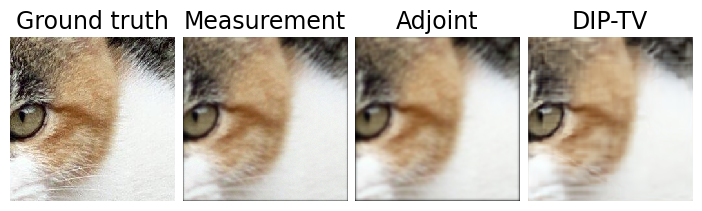

In [ ]:
# kernel (1,1,K,K) déjà construit
physics = BlurSame(kernel4d, sigma=2/255.0)

y = physics(x)

x_diptv = dip_optimize(
    y, physics,
    lam_tv=5e-3,
    iterations=3000,
    lr=1e-2,
    channels=64,
    in_size=(2,2),
    seed=0
)

x_adj = physics.A_adjoint(y)

if psnr is not None:
    print("PSNR adjoint:", psnr(x, x_adj).item())
    print("PSNR DIP-TV :", psnr(x, x_diptv).item())

plot({"Ground truth": x, "Measurement": y, "Adjoint": x_adj, "DIP-TV": x_diptv})


La figure présente les résultats du défloutage obtenus avec l’adjoint et la méthode DIP-TV. On observe que la reconstruction obtenue avec l’adjoint reste peu nette, tandis que la méthode DIP-TV apporte une amélioration de la qualité de l’image reconstruite.

Ces résultats sont cohérents avec les valeurs de PSNR : l’adjoint atteint environ 22.08 dB, alors que la méthode DIP-TV atteint environ 24.7 dB. On constate donc que l’utilisation de la méthode DIP-TV améliore la qualité du défloutage des images.

# Conclusion

Dans ce projet, nous avons étudié l’article Image Restoration using Total Variation Regularized Deep Image Prior. Nous avons d’abord présenté le problème inverse considéré dans l’article, à savoir la restauration d’images dégradées. Nous avons ensuite décrit la méthode proposée, DIP-TV, en l’expliquant et en l’implémentant. Enfin, nous avons reproduit partiellement les expériences de l’article sur les problèmes de débruitage et de défloutage.

Les résultats obtenus montrent que l’utilisation de la méthode DIP-TV améliore les performances du DIP seul, en particulier lorsque le niveau de bruit est élevé. L’ajout de la régularisation TV permet de stabiliser la reconstruction et d’améliorer la qualité des images restaurées.

Ces observations sont cohérentes avec l’article et montrent qu’il est pertinent de combiner le prior implicite du DIP avec la régularisation TV pour les problèmes de restauration d’images.